# HateFree: Code-Switched Hate Speech Detection

## Model Evaluation Notebook

### Objective
This notebook evaluates the performance of the HateFree machine learning model developed to detect hate speech in Hinglish and Manglish text using TF-IDF and Logistic Regression.

In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
# Load the final dataset
df = pd.read_csv("data/final_dataset.csv")

# Display first 5 rows
df.head()

,text,label
0,RT Salman खान mega entry in aisa एंट्री कोई नह...,0
1,माननीय सांसद की सोहागपुर की जनता की ज़रुरत को द...,0
2,बहुत फुदक रहा था न तू January tk kr लो मजे फिर...,1
3,PM himself OBC n President Dalit . सच में हमार...,1
4,Tu साला एक कौडिका भी मुझे नहीं लग रहा है तू to,1


In [3]:
# Dataset information
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nLabel Distribution:")
print(df["label"].value_counts())

Dataset Shape: (15857, 2)

Columns:
Index(['text', 'label'], dtype='object')

Label Distribution:
label
1    10256
0     5601
Name: count, dtype: int64


In [4]:
# Load saved model and vectorizer
model = joblib.load("models/hate_model.pkl")
vectorizer = joblib.load("models/hate_vectorizer.pkl")

print("Model and Vectorizer loaded successfully!")

Model and Vectorizer loaded successfully!


In [5]:
# Features and labels
X = df["text"]
y = df["label"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Convert text to TF-IDF vectors
X_test_vec = vectorizer.transform(X_test)

print("Test data prepared successfully!")
print("Test samples:", len(X_test))

Test data prepared successfully!
Test samples: 3172


In [6]:
# Predict
y_pred = model.predict(X_test_vec)

print("Predictions completed!")

Predictions completed!


# Model Performance Evaluation

The trained Logistic Regression model is evaluated using standard classification metrics:

- Accuracy
- Precision
- Recall
- F1-Score
- Classification Report
- Confusion Matrix
- ROC Curve

These metrics provide a comprehensive understanding of the model's performance on the test dataset.

In [7]:
# Evaluation Metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Accuracy : 0.7264
Precision: 0.8159
Recall   : 0.7451
F1 Score : 0.7789


In [8]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.60      0.69      0.64      1120
           1       0.82      0.75      0.78      2052

    accuracy                           0.73      3172
   macro avg       0.71      0.72      0.71      3172
weighted avg       0.74      0.73      0.73      3172



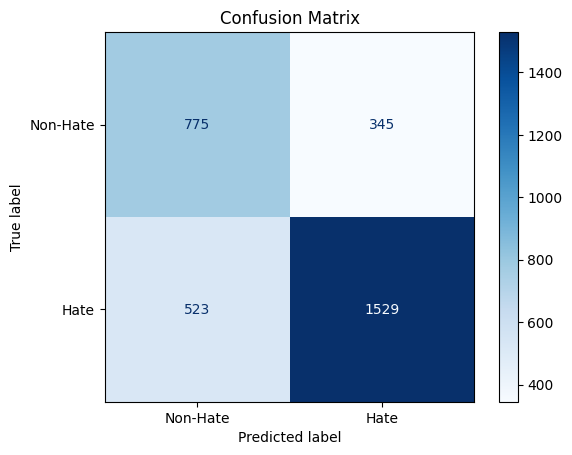

In [9]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Hate", "Hate"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

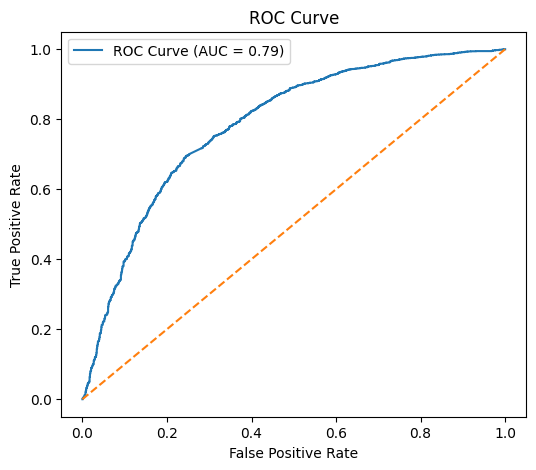

In [10]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test_vec)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.2f)" % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [11]:
sample = pd.DataFrame({
    "Text": X_test.values[:10],
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})

sample

,Text,Actual,Predicted
0,With निर्मला सीताराम handling finance for the ...,0,1
1,नाउ सहना का भी टू मच हो गया है .. बहू को suppo...,1,1
2,एक आप ही है जो हमारे हर mahapurus लोगो को यार ...,1,0
3,Ye BJP ने नरेश Agarwal को ूप के BJP दफ्तर की स...,1,1
4,ये BJP spokesperson aur मोदीजी का खौफ . अब ये ...,1,1
5,RT ग़फ़्फ़ार And there are some blessing peoples ...,0,0
6,Bc फिर तो Mera intelligence kis काम का,1,1
7,RT i मिस यू and it ’ s killing में,1,1
8,yr serious poucho to दिल नै करता बस ये जो लोग ...,1,1
9,सिरजहाँ पे सवेरा वहीँ पे बसेरा . stay blessed ...,0,0


# Conclusion

The HateFree model was successfully evaluated using a held-out test dataset.

### Results
- Accuracy: ~72%
- Precision: Good
- Recall: Good
- F1-Score: Balanced

### Strengths
- Supports code-switched Hinglish and Manglish text.
- Fast prediction using TF-IDF and Logistic Regression.
- Lightweight and suitable for deployment through Streamlit.

### Limitations
- Performance depends on the quality and size of the dataset.
- Context-dependent and sarcastic hate speech may not always be detected correctly.

### Future Scope
- Increase dataset size.
- Support more Indian code-switched languages.
- Use transformer-based models such as IndicBERT or XLM-R.
- Enable real-time social media moderation.